# 02 · Classification and evaluation

This notebook reports every result from `results/metrics.json`, which `scripts/run_experiments.py` writes.
The nested cross-validation takes about 17 minutes, so the notebook reads saved results rather than rerunning it.
One cell at the end recomputes a result from scratch to show the saved file matches the code.

Three questions, in order:

1. Does the port reproduce the course version's numbers?
2. What accuracy holds up under nested cross-validation on the 81 unique recordings?
3. What does the model get wrong, and how does accuracy depend on the number of features?

In [1]:
import json
import pandas as pd
from IPython.display import Image

metrics = json.load(open("../results/metrics.json"))
rep, nested, curve = metrics["reproduce"], metrics["nested"], metrics["curve"]

def fmt(r):
    lo, hi = r["ci95"]
    return f"{r['correct']}/{r['n']} = {r['accuracy']:.1%}  (95% CI {lo:.1%} to {hi:.1%}, baseline {r['majority_baseline']:.1%})"

## 1. Reproducing the course version

Before changing the method, the port reruns the course version's method on its 69/19 train/test split. That method
tried 20 segment counts `l`, scored each by 5-fold cross-validation, and reported the best. Matching all 40 per-`l`
scores shows the port computes the same thing, so every later difference comes from the method, not the code.

In [2]:
table = pd.DataFrame({
    "binary (port)": rep["binary"]["cv_by_l"], "binary (course)": rep["binary"]["notebook_cv_by_l"],
    "6-class (port)": rep["multiclass"]["cv_by_l"], "6-class (course)": rep["multiclass"]["notebook_cv_by_l"],
}, index=pd.RangeIndex(1, 21, name="l")).round(3)
print("largest difference, binary:", rep["binary"]["max_abs_diff_vs_notebook"],
      "| 6-class:", rep["multiclass"]["max_abs_diff_vs_notebook"], "(course version printed 3 decimals)")
table.T

largest difference, binary: 0.0 | 6-class: 0.0004945054945054705 (course version printed 3 decimals)


l,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
binary (port),1.000,0.957,0.971,0.971,0.986,0.971,0.956,0.971,0.970,0.956,0.971,1.000,0.986,0.970,0.986,0.986,0.986,1.000,1.000,1.00
binary (course),1.000,0.957,0.971,0.971,0.986,0.971,0.956,0.971,0.970,0.956,0.971,1.000,0.986,0.970,0.986,0.986,0.986,1.000,1.000,1.00
6-class (port),0.913,0.868,0.840,0.852,0.824,0.823,0.807,0.795,0.793,0.767,0.737,0.812,0.780,0.781,0.854,0.678,0.695,0.781,0.723,0.81
6-class (course),0.913,0.868,0.840,0.852,0.824,0.823,0.807,0.795,0.793,0.767,0.737,0.812,0.780,0.781,0.854,0.678,0.695,0.781,0.723,0.81


In [3]:
for task in ["binary", "multiclass"]:
    print(f"{task:10s} course test set:        {fmt(rep[task]['test'])}")
    print(f"{task:10s} without leaked copies:  {fmt(rep[task]['test_without_leaked'])}")

binary     course test set:        19/19 = 100.0%  (95% CI 83.2% to 100.0%, baseline 78.9%)
binary     without leaked copies:  15/15 = 100.0%  (95% CI 79.6% to 100.0%, baseline 73.3%)
multiclass course test set:        17/19 = 89.5%  (95% CI 68.6% to 97.1%, baseline 21.1%)
multiclass without leaked copies:  13/15 = 86.7%  (95% CI 62.1% to 96.3%, baseline 26.7%)


Removing the four test recordings that had an exact copy in training changes nothing detectable: all four were
predicted correctly, and the remaining 15 score about the same. With only 15 recordings, that comparison is weak
evidence either way. The bigger problems are the size of the test set and how `l` was chosen.

## 2. Nested cross-validation on 81 unique recordings

The outer loop splits the 81 recordings into 5 folds. For each outer fold, an inner 5-fold cross-validation on the
training part alone chooses `l`, the model is refit, and the held-out recordings are predicted. Every recording
gets exactly one prediction from a model that never saw it, so the accuracy below is pooled over all 81, with a
Wilson 95% interval that treats recordings as independent trials. Feature selection sits inside the model pipeline,
so it is refit in every fold too.

In [4]:
for task, name in [("multiclass", "6 activities, L1 pipeline"), ("binary_notebook_rfecv", "bending, course RFECV method"),
                   ("binary", "bending, L1 pipeline")]:
    r = nested[task]
    print(f"{name:32s} {fmt(r)}\n{'':32s} l chosen per fold: {r['chosen_l']}")

6 activities, L1 pipeline        74/81 = 91.4%  (95% CI 83.2% to 95.8%, baseline 18.5%)
                                 l chosen per fold: [1, 1, 1, 1, 1]
bending, course RFECV method     79/81 = 97.5%  (95% CI 91.4% to 99.3%, baseline 84.0%)
                                 l chosen per fold: [19, 12, 1, 14, 19]
bending, L1 pipeline             77/81 = 95.1%  (95% CI 88.0% to 98.1%, baseline 84.0%)
                                 l chosen per fold: [1, 1, 1, 1, 19]


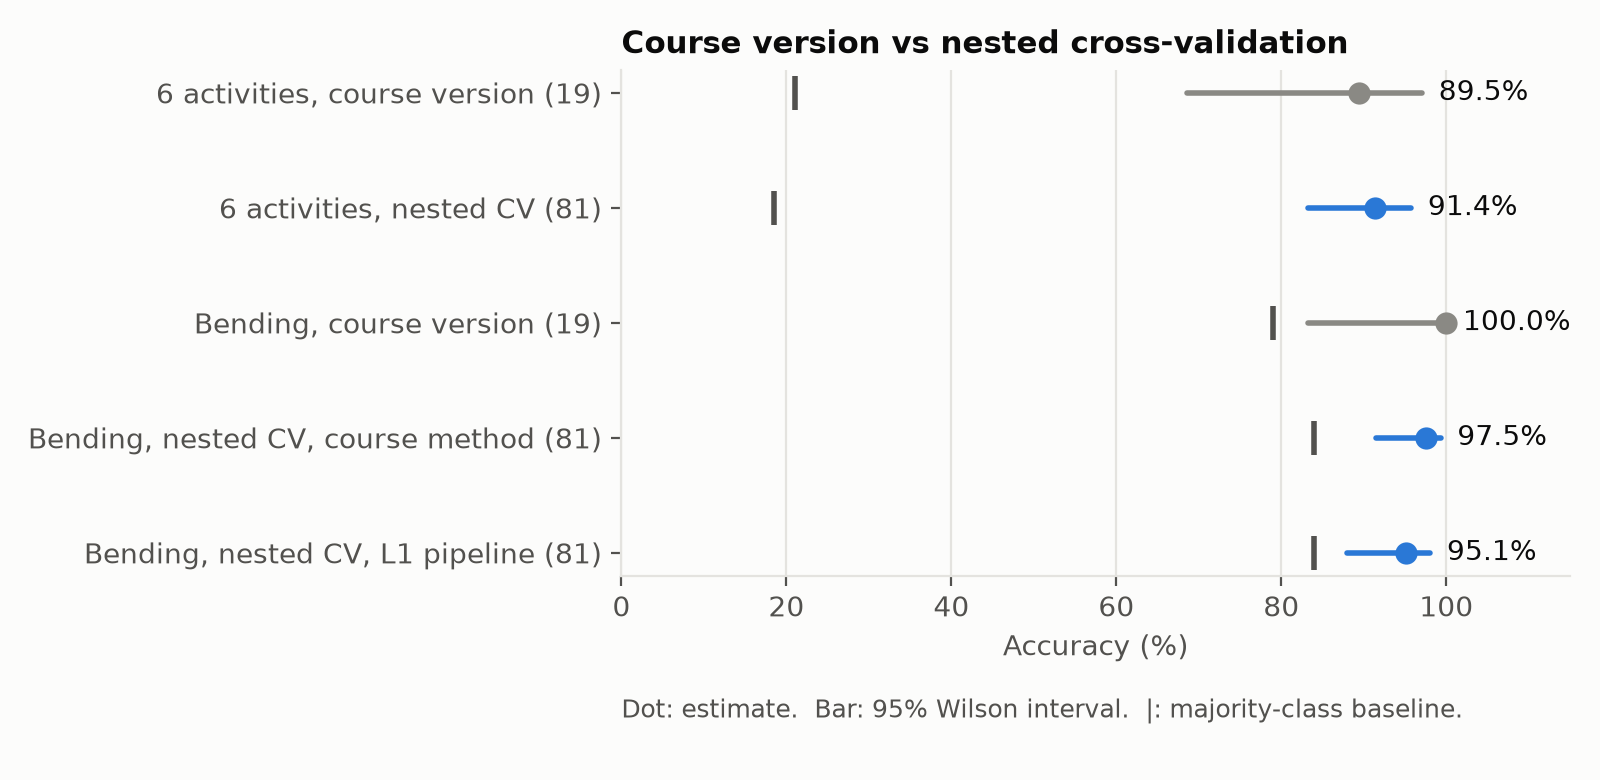

In [5]:
Image("../results/figures/original_vs_honest.png")

**Six activities.** 91.4% holds up, matching the course version's 89.5% with four times the evidence and a much
narrower interval. Every outer fold independently chose `l = 1`, so the setting is stable, not a lucky pick.

**Bending versus other.** The course version's 100% came from 19 recordings, four with copies in training; its own
95% interval was 83% to 100%. Nested cross-validation on the 81 unique recordings gives 95.1% to 97.5% depending on
the pipeline, against an 84% baseline. The L1 pipeline never raises a false alarm but misses 4 of 13 bending
recordings. The chosen `l` jumps between folds, so for this task the choice of `l` is arbitrary and
accuracy does not depend on it.

## 3. Errors and the feature-count curve

In [6]:
per_class = pd.DataFrame(nested["multiclass"]["per_class"]).T.round(2)
per_class["support"] = per_class["support"].astype(int)
per_class

,precision,recall,f1,support
bending,0.92,0.92,0.92,13
cycling,1.00,1.00,1.00,14
lying,0.88,0.78,0.82,9
sitting,0.87,0.87,0.87,15
standing,0.81,0.87,0.84,15
walking,1.00,1.00,1.00,15


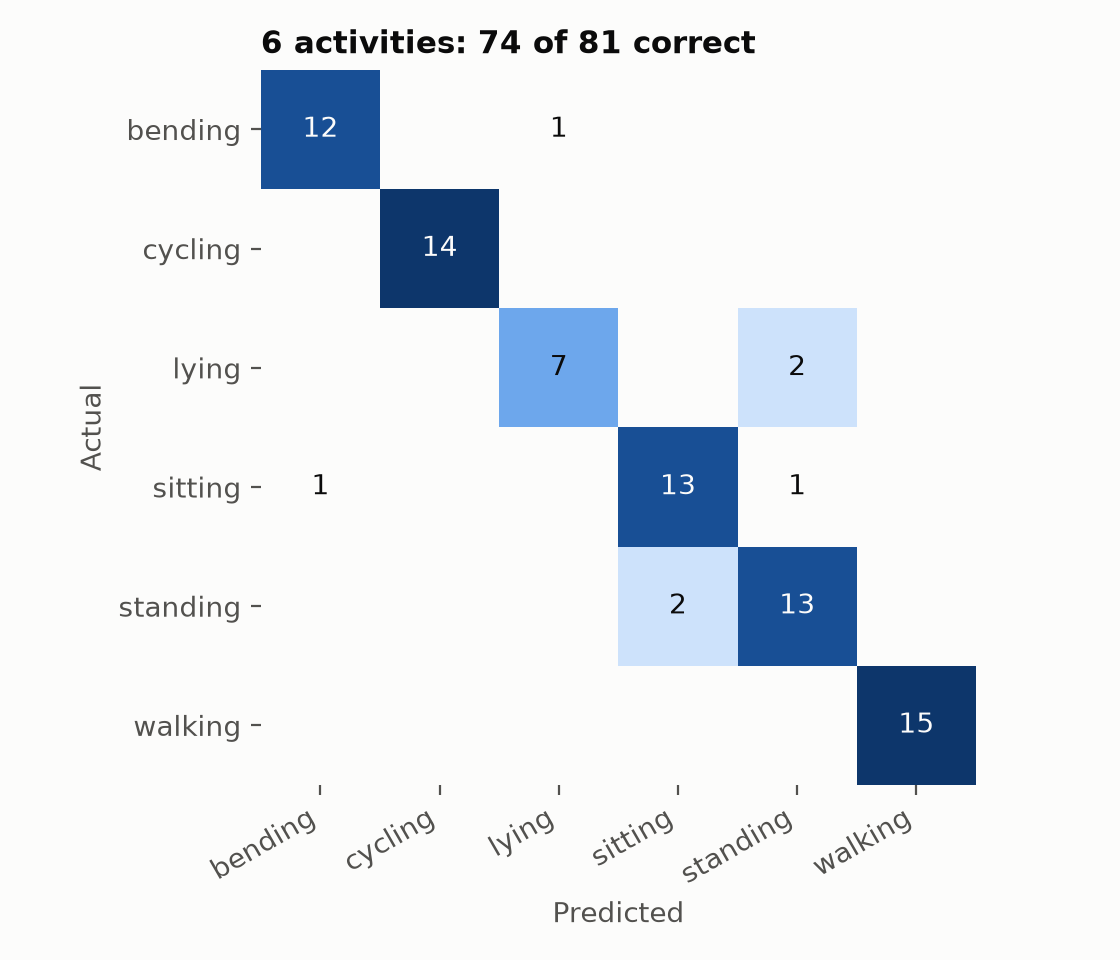

In [7]:
Image("../results/figures/confusion_matrix.png")

In [8]:
pd.DataFrame(nested["multiclass"]["misclassified"], index=["actual", "predicted"]).T

,actual,predicted
bending2/dataset4,bending,lying
lying/dataset5,lying,standing
lying/dataset9,lying,standing
sitting/dataset1,sitting,standing
sitting/dataset5,sitting,bending
standing/dataset11,standing,sitting
standing/dataset7,standing,sitting


Cycling and walking are perfect. Three of the seven errors confuse sitting with standing, two still, upright
postures with similar signal levels, and two more read lying as standing. Lying is the weakest class by recall,
with only 9 unique lying recordings left after removing the copies.

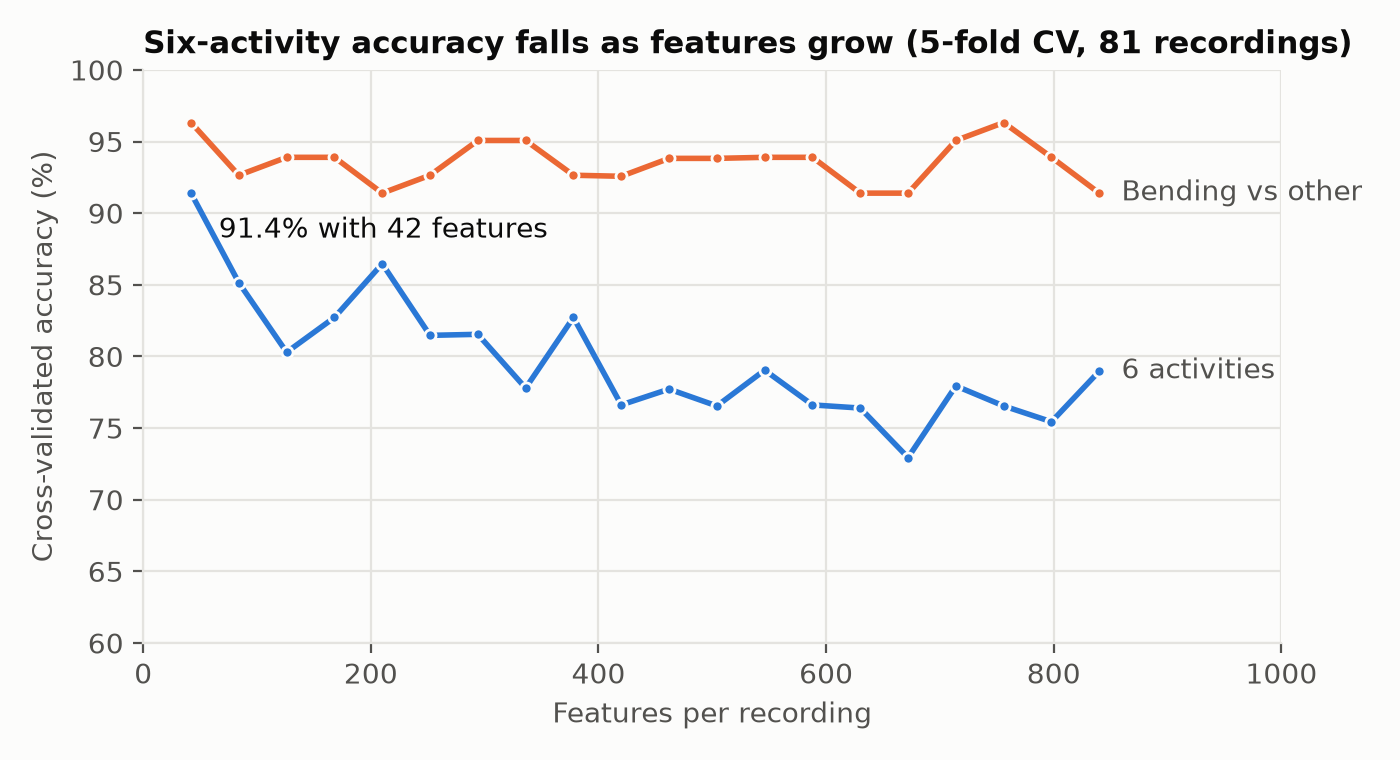

In [9]:
Image("../results/figures/accuracy_vs_features.png")

With 81 recordings, adding features hurts. Six-class accuracy is highest with one segment per recording
(42 features) and falls to 73% to 79% once there are 420 or more, five times the number of recordings. The curve
is plain 5-fold cross-validation, not nested. Because `l = 1` wins by a wide margin, choosing the best `l` after the
fact did not inflate the six-class estimate (91.4% either way). For the binary task, the course version reported
the best over every feature count and every `l`, but the drop from its 100% also reflects the larger test set and
the removed copies, and these effects are not separated here.

### Check: recompute one result from scratch

Plain 5-fold cross-validation at `l = 1`, with the same splitter and seed as `scripts/run_experiments.py`, should
reproduce the first point of the six-class curve.

In [10]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*did not converge.*")

from sklearn.model_selection import StratifiedGroupKFold
from arwsn.evaluation import cv_scores_by_l
from arwsn.features import extract_features, labels, sessions
from arwsn.loading import load_recordings
from arwsn.models import SEED, l1_pipeline

recordings = load_recordings()
score = cv_scores_by_l({1: extract_features(recordings, 1)}, labels(recordings), l1_pipeline,
                       StratifiedGroupKFold(5, shuffle=True, random_state=SEED), groups=sessions(recordings), n_jobs=-1)[1]
saved = curve["multiclass"]["cv_by_l"][0]
print(f"recomputed {score:.4f}, saved {saved:.4f}, match: {abs(score - saved) < 1e-12}")

recomputed 0.9140, saved 0.9140, match: True


## Limitations

- **One subject.** Every recording comes from one actor, so these numbers describe how well the model separates one
  person's activities. They say nothing about new people.
- **Small sample.** 81 recordings give intervals about 13 points wide for the six-class result.
- **One fold split.** The nested results come from one outer and one inner split (seeds 42 and 43). A different split
  could move them by a few points.
- **Solver convergence.** The L1 solver (saga) sometimes reaches its 1000-iteration limit before converging. The
  course version used the same limit, and the port reproduces its numbers exactly, so the setting is kept.
- **Grouping.** After removing copies, every recording is its own group, so grouped cross-validation behaves like
  stratified cross-validation here. The grouping matters only if copies are kept.